#  TRICARE 전처리

---

## 1. 청구서 데이터 로드

In [10]:
import pandas as pd
import numpy as np
import pdfplumber

In [11]:
tricare_claim=pdfplumber.open('C://SKN_24//4차 프로젝트 개인//전처리//TRICARE//data//dd2642.pdf')
tricare_claim

In [12]:
#len(tricare_claim.pages)

In [13]:
#p0 = tricare_claim.pages[0]
#p1 = tricare_claim.pages[1]
#
#print(p0.page_number)
#print(p1.page_number)

In [14]:
#im=p0.to_image()
#im=p1.to_image()
#im

In [15]:
#p0.extract_text()

In [16]:
#print(p0.extract_text())

---

# 2. 청구서와 함께 제출할 데이터 로드

In [17]:
tricare_document=pdfplumber.open('C://SKN_24//4차 프로젝트 개인//전처리//TRICARE//data//dd2527.pdf')
tricare_document

In [18]:
#len(tricare_document.pages)
p0=tricare_document.pages[0]
p1=tricare_document.pages[1]

print(p0.page_number)
print(p1.page_number)


1
2


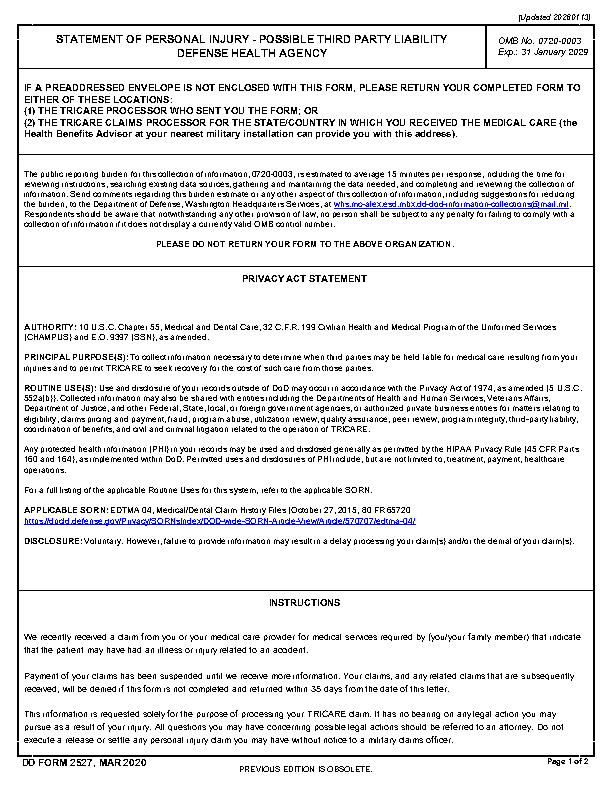

In [19]:
im=p0.to_image()
#im=p1.to_image()
im

In [20]:
p0.extract_text()

'(Updated 20260113)\nSTATEMENT OF PERSONAL INJURY - POSSIBLE THIRD PARTY LIABILITY OMB No. 0720-0003\nDEFENSE HEALTH AGENCY Exp.: 31 January 2029\nIF A PREADDRESSED ENVELOPE IS NOT ENCLOSED WITH THIS FORM, PLEASE RETURN YOUR COMPLETED FORM TO\nEITHER OF THESE LOCATIONS:\n(1) THE TRICARE PROCESSOR WHO SENT YOU THE FORM; OR\n(2) THE TRICARE CLAIMS PROCESSOR FOR THE STATE/COUNTRY IN WHICH YOU RECEIVED THE MEDICAL CARE (the\nHealth Benefits Advisor at your nearest military installation can provide you with this address).\nThe public reporting burden for this collection of information, 0720-0003, is estimated to average 15 minutes per response, including the time for\nreviewing instructions, searching existing data sources, gathering and maintaining the data needed, and completing and reviewing the collection of\ninformation. Send comments regarding this burden estimate or any other aspect of this collection of information, including suggestions for reducing\nthe burden, to the Department o

---

# 3. 각 파일별 데이터 전처리

In [45]:
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

PDF = [
    {
        "pdf_path": str(DATA_DIR / "dd2642.pdf"),
        "doc_id": "tricare_dd2642_sep2024",
        "source_file": "dd2642.pdf",
        "form_name": "DD Form 2642",
        "form_title": "TRICARE DoD/CHAMPUS Medical Claim",
        "doc_type": "claim_form",
        "retrieval_scope": "procedure",
        "updated_at": "2025-09-23"
    },
    {
        "pdf_path": str(DATA_DIR / "dd2527.pdf"),
        "doc_id": "tricare_dd2527_mar2020",
        "source_file": "dd2527.pdf",
        "form_name": "DD Form 2527",
        "form_title": "Statement of Personal Injury - Possible Third Party Liability",
        "doc_type": "injury_statement_form",
        "retrieval_scope": "procedure",
        "updated_at": "2026-01-13"
    }
]

In [46]:
#로드 잘 됐는지 확인
for pdf in PDF:
    print("파일:", pdf["pdf_path"])

    with pdfplumber.open(pdf["pdf_path"]) as doc:
        print("페이지 수:", len(doc.pages))

    print("-" * 50)

파일: c:\SKN_24\4차 프로젝트 개인\전처리\TRICARE\data\dd2642.pdf
페이지 수: 2
--------------------------------------------------
파일: c:\SKN_24\4차 프로젝트 개인\전처리\TRICARE\data\dd2527.pdf
페이지 수: 2
--------------------------------------------------


In [47]:
COMMON_METADATA = {
    "insurer": "TRICARE",
    "language": "en",
    "audience": "foreign_residents_in_korea",
    "country_context": "Korea",
    "keep_for_rag": True
}

In [48]:
# 필요 없는 내용 제거

import re

def clean_common(text: str):
    patterns = [
        r"PREVIOUS EDITION IS OBSOLETE\.?",
        r"Page \d of \d",
        r"DD FORM \d+, [A-Z]{3} \d{4}",
        r"\(Updated \d+\)",
        r"OMB No\.\s*\d+-\d+",
        r"Exp\.:.*?\d{4}",
        r"CUI \(when filled in\)",
        r"DEFENSE HEALTH AGENCY",
    ]

    cleaned = text
    for p in patterns:
        cleaned = re.sub(p, "", cleaned)

    return cleaned.strip()

In [49]:

#dd2642 전용
def clean_dd2642(text: str):
    cleaned = clean_common(text)

    patterns = [
        r"Prescribed by:.*",
        r"April 2015 & TRICARE Operations Manual.*",
        r"OMB approval expires.*",
        r"PATIENT'S REQUEST FOR MEDICAL PAYMENT\s*\d{8}",

        #행정 부담 문구
        r"The public reporting burden[\s\S]*?currently valid OMB control number\.",
    ]

    for p in patterns:
        cleaned = re.sub(p, "", cleaned)

    return re.sub(r"\n{3,}", "\n\n", cleaned).strip()

In [50]:
#dd2527 전용
def clean_dd2527(text: str):
    cleaned = clean_common(text)

    patterns = [
        r"STATEMENT OF PERSONAL INJURY - POSSIBLE THIRD PARTY LIABILITY",
        r"OMB No\.\s*\d+-\d+",
        r"Exp\.:.*",

        #제출처 혼동 방지용 내용이라 제거함
        r"PLEASE DO NOT RETURN YOUR FORM TO THE ABOVE ORGANIZATION\.",
        # 행정 부담 문구 제거
        r"The public reporting burden[\s\S]*?currently valid OMB control number\.",
    ]

    for p in patterns:
        cleaned = re.sub(p, "", cleaned)

    cleaned = re.sub(r"\n{3,}", "\n\n", cleaned)
    cleaned = re.sub(r"[ \t]+", " ", cleaned)

    return cleaned.strip()

In [51]:
#파일명에 따라 다르게 적용
def clean_text(text: str, source_file: str):
    if source_file == "dd2642.pdf":
        return clean_dd2642(text)
    elif source_file == "dd2527.pdf":
        return clean_dd2527(text)
    else:
        return clean_common(text)

In [52]:
# dd2642 확인
with pdfplumber.open(DATA_DIR / "dd2642.pdf") as doc:
    sample_text = doc.pages[0].extract_text()

cleaned = clean_text(sample_text, "dd2642.pdf")

print("RAW:\n", sample_text[:300])
print("\nCLEAN:\n", cleaned[:1000])

RAW:
 Prescribed by: TRICARE Reimbursement Manual 6010.61-M,
CUI (when filled in)
April 2015 & TRICARE Operations Manual 6010.59-M, April 2015 (Updated 20250923)
OMB No. 0720-0006
TRICARE DoD/CHAMPUS MEDICAL CLAIM
OMB approval expires
PATIENT'S REQUEST FOR MEDICAL PAYMENT 20280229
The public reporting bur

CLEAN:
 TRICARE DoD/CHAMPUS MEDICAL CLAIM

RETURN COMPLETED FORM TO THE APPROPRIATE CLAIMS PROCESSOR. IF YOU DO NOT KNOW WHO YOUR CLAIMS PROCESSOR IS,
PLEASE VISIT: www.tricare.mil/ContactUs/CallUs.
PRIVACY ACT STATEMENT
AUTHORITY: 10 U.S.C. Chapter 55, Medical and Dental Care; 32 C.F.R. 199 Civilian Health and Medical Program of the Uniformed Services (CHAMPUS) and
E.O. 9397 (SSN), as amended.
PRINCIPAL PURPOSE(S): To determine eligibility for medical care under the TRICARE program, determine other health insurance's liability, certify that the
medical care was received, and reimbursement for medical services received are authorized by law.
ROUTINE USE(S): Use and disclosure of your

In [53]:
# dd2527 확인
with pdfplumber.open(DATA_DIR / "dd2527.pdf") as doc:
    sample_text = doc.pages[0].extract_text()

cleaned = clean_text(sample_text, "dd2527.pdf")

print("RAW:\n", sample_text[:300])
print("\nCLEAN:\n", cleaned[:1000])

RAW:
 (Updated 20260113)
STATEMENT OF PERSONAL INJURY - POSSIBLE THIRD PARTY LIABILITY OMB No. 0720-0003
DEFENSE HEALTH AGENCY Exp.: 31 January 2029
IF A PREADDRESSED ENVELOPE IS NOT ENCLOSED WITH THIS FORM, PLEASE RETURN YOUR COMPLETED FORM TO
EITHER OF THESE LOCATIONS:
(1) THE TRICARE PROCESSOR WHO SENT

CLEAN:
 IF A PREADDRESSED ENVELOPE IS NOT ENCLOSED WITH THIS FORM, PLEASE RETURN YOUR COMPLETED FORM TO
EITHER OF THESE LOCATIONS:
(1) THE TRICARE PROCESSOR WHO SENT YOU THE FORM; OR
(2) THE TRICARE CLAIMS PROCESSOR FOR THE STATE/COUNTRY IN WHICH YOU RECEIVED THE MEDICAL CARE (the
Health Benefits Advisor at your nearest military installation can provide you with this address).

PRIVACY ACT STATEMENT
AUTHORITY: 10 U.S.C. Chapter 55, Medical and Dental Care; 32 C.F.R. 199 Civilian Health and Medical Program of the Uniformed Services
(CHAMPUS) and E.O. 9397 (SSN), as amended.
PRINCIPAL PURPOSE(S): To collect information necessary to determine when third parties may be held liable for me

In [54]:
def load_pdf_pages(pdf_path: str, source_file: str):
    pages = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            raw_text = page.extract_text() or ""

            pages.append({
                "page": page.page_number,
                "raw_text": raw_text,
                "clean_text": clean_text(raw_text, source_file)
            })

    return pages

In [55]:
def extract_between(text: str, start: str, end: str | None = None) -> str:
    start_idx = text.find(start)

    if start_idx == -1:
        return ""

    if end is None:
        return text[start_idx:].strip()

    end_idx = text.find(end, start_idx + len(start))

    if end_idx == -1:
        return text[start_idx:].strip()

    return text[start_idx:end_idx].strip()

In [56]:
#섹션 규칙
SECTION_RULES = {
    "dd2642.pdf": [
        {
            "section_id": "claim_overview",
            "section_title": "Claim Form Overview",
            "page": 1,
            "start": "TRICARE DoD/CHAMPUS MEDICAL CLAIM",
            "end": "PRIVACY ACT STATEMENT",
            "topic": ["claims", "overview"]
        },
        {
            "section_id": "important_claim_instructions",
            "section_title": "Important Claim Instructions",
            "page": 1,
            "start": "IMPORTANT - READ CAREFULLY",
            "end": "WHERE TO OBTAIN ADDITIONAL FORMS",
            "topic": ["claims", "itemized_bill", "deadline", "prescription", "overseas_claim"]
        },
        {
            "section_id": "how_to_fill_out_form",
            "section_title": "How to Fill Out Claim Form",
            "page": 2,
            "start": "HOW TO FILL OUT THE TRICARE/CHAMPUS FORM",
            "end": None,
            "topic": ["claims", "form_instruction", "other_health_insurance"]
        }
    ],

    "dd2527.pdf": [
        {
            "section_id": "injury_form_instructions",
            "section_title": "Personal Injury Form Instructions",
            "page": 1,
            "start": "INSTRUCTIONS",
            "end": None,
            "topic": ["claims", "injury", "third_party_liability", "deadline"]
        },
        {
            "section_id": "injury_general_information",
            "section_title": "General Information Fields",
            "page": 2,
            "start": "SECTION I - GENERAL INFORMATION",
            "end": "SECTION II - TYPE AND CAUSE OF INJURY",
            "topic": ["injury", "form_fields"]
        },
        {
            "section_id": "injury_type_and_cause",
            "section_title": "Type and Cause of Injury",
            "page": 2,
            "start": "SECTION II - TYPE AND CAUSE OF INJURY",
            "end": "SECTION III - MISCELLANEOUS",
            "topic": ["injury", "accident", "third_party_liability"]
        },
        {
            "section_id": "injury_miscellaneous",
            "section_title": "Miscellaneous Injury Information",
            "page": 2,
            "start": "SECTION III - MISCELLANEOUS",
            "end": None,
            "topic": ["injury", "insurance", "lawyer", "signature"]
        }
    ]
}

In [57]:
from pathlib import Path
import json

def preprocess_pdf(config: dict):
    pages = load_pdf_pages(config["pdf_path"], config["source_file"])
    rules = SECTION_RULES[config["source_file"]]

    results = []

    for rule in rules:
        page_text = pages[rule["page"] - 1]["clean_text"]

        text = extract_between(
            page_text,
            rule["start"],
            rule["end"]
        )

        if not text:
            continue

        item = {
            **COMMON_METADATA,
            **config,
            "section_id": rule["section_id"],
            "section_title": rule["section_title"],
            "page_start": rule["page"],
            "page_end": rule["page"],
            "topic": rule["topic"],
            "text": text
        }

        results.append(item)

    return results

In [58]:
all_sections = []

for config in PDF:
    sections = preprocess_pdf(config)
    all_sections.extend(sections)

output_path = BASE_DIR / "outputs" / "json_docs" / "tricare_forms.json"
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(all_sections, f, ensure_ascii=False, indent=2)

print(f"저장 완료: {output_path}")
print(f"총 섹션 수: {len(all_sections)}")

저장 완료: c:\SKN_24\4차 프로젝트 개인\전처리\TRICARE\outputs\json_docs\tricare_forms.json
총 섹션 수: 7


In [59]:
for section in all_sections:
    print(section["source_file"], "|", section["section_title"])
    print(section["text"][:200])
    print("-" * 80)

dd2642.pdf | Claim Form Overview
TRICARE DoD/CHAMPUS MEDICAL CLAIM

RETURN COMPLETED FORM TO THE APPROPRIATE CLAIMS PROCESSOR. IF YOU DO NOT KNOW WHO YOUR CLAIMS PROCESSOR IS,
PLEASE VISIT: www.tricare.mil/ContactUs/CallUs.
--------------------------------------------------------------------------------
dd2642.pdf | Important Claim Instructions
IMPORTANT - READ CAREFULLY
Use this form if your provider doesn't file a claim for you. If you receive care overseas you can register on the secure claims portal to file your overseas claim
online at 
--------------------------------------------------------------------------------
dd2642.pdf | How to Fill Out Claim Form
HOW TO FILL OUT THE TRICARE/CHAMPUS FORM
You must attach an itemized bill (see front of form) from your doctor/supplier for CHAMPUS to process this claim.
11. By law, you must report if the patient is
--------------------------------------------------------------------------------
dd2527.pdf | Personal Injury Form Instructions
IN